## testing ground for motif search algorithms
### plan of action:
- implement grochow kellis algorithm
- implement onion decomposition
    - count how many non isomorphic graphs are discriminated by onion layer
- implement shamir and tsur O(k^1.5n) subtree isomorphism algorithm and integrate it with grochow kellis
- implement a good ear decomposition algorithm
- implement other algorithms for comparison
- put it all together (in sequential stages)
- interface with java for speedup?
- custom visualization library?
- parallellize?

### networkx hello world:

In [574]:
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)
# nx.draw_spring(G, with_labels=True)

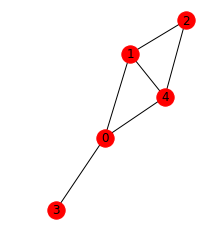

In [437]:
plt.subplot(121)
nx.draw_spring(H, with_labels=True)

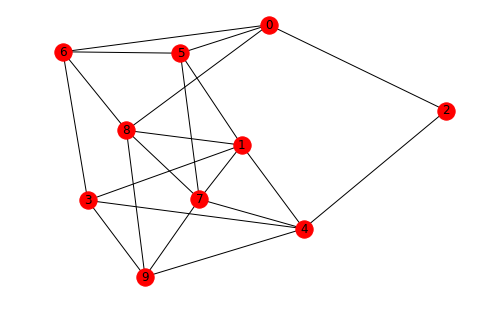

In [350]:
# plt.subplot(121)
nx.draw_spring(G, with_labels=True)

In [ ]:
H2 = nx.Graph()
H2.add_nodes_from([0,1,2,3,4,5])
H2.add_edges_from([(0,1), (1, 2), (2, 0), (4, 3), (3, 5), (5, 4), (0, 3)])
nx.draw_spring(H2, with_labels=True)

## CONSOLE

In [1151]:
# now we shall fix the automorphisms of H whence they be
aut = fn.findSubgraphInstances(H, H)

# fn.findEquivalenceClasses(aut)
M = fn.symmetryConditions(aut)
M

# [k.getMap() for k in aut]

{0: set(), 1: {4}, 2: set(), 3: set()}

In [1145]:
t = [tuple(k.getMap()) for k in aut]  # maps of aut turned into tuples
dummy = []
to_return = []

for key, value in enumerate(t):
    if (value not in dummy):
        dummy.append(value)
        to_return.append(aut[key])
        
[k.getMap() for k in to_return]

0
((0, 0), (1, 1), (2, 2), (3, 3), (4, 4))
1
((0, 0), (1, 1), (2, 2), (3, 3), (4, 4))
2
((0, 0), (1, 1), (2, 2), (3, 3), (4, 4))
3
((0, 0), (1, 1), (2, 2), (3, 3), (4, 4))
4
((0, 0), (1, 4), (2, 2), (3, 3), (4, 1))
5
((0, 0), (1, 4), (2, 2), (3, 3), (4, 1))
6
((0, 0), (1, 1), (2, 2), (3, 3), (4, 4))


[array([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)],
       dtype=[('domainNode', '<i4'), ('rangeNode', '<i4')]),
 array([(0, 0), (1, 4), (2, 2), (3, 3), (4, 1)],
       dtype=[('domainNode', '<i4'), ('rangeNode', '<i4')])]

In [1130]:
instances = []

# for f in aut:
#     if(tuple([tuple(k) for k in f.getMap()]) not in instances):
#         instances.append(f)
#         print(f.getMap())
        
# tuple([tuple(k) for k in f.getMap()])
f.getMap()

array([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)],
      dtype=[('domainNode', '<i4'), ('rangeNode', '<i4')])

In [1146]:
f1 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)])
f2 = fn.Map([(0, 0), (1, 1), (2, 2), (3, 3), (4, 5), (5, 4)])
f3 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 4), (5, 5)])
f4 = fn.Map([(0, 0), (1, 2), (2, 1), (3, 3), (4, 5), (5, 4)])
f5 = fn.Map([(0, 3), (1, 4), (2, 5), (3, 0), (4, 1), (5, 2)])
f6 = fn.Map([(0, 3), (1, 5), (2, 4), (3, 0), (4, 2), (5, 1)])

autH2 = [f1, f2, f3, f4, f5, f6]  # set of automorphisms of H2
eq = fn.findEquivalenceClasses(autH2)
M = fn.symmetryConditions(autH2)

[t for t in f1.getMap()]

[(0, 0), (1, 1), (2, 2), (3, 3), (4, 4), (5, 5)]

In [1149]:
import numpy as np
import pandas as pd
import networkx as nx
import functions as fn
import matplotlib.pyplot as plt
import importlib
import numpy.lib.recfunctions as rfn
importlib.reload(fn)

G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)